# Engine Failure Detection Using EngineFaultDB Dataset
# **Step 1: Importing libraries and load dataset**

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
df = pd.read_csv("EngineFaultDB_Final.csv")

# Merge Fault 2 and Fault 3 (mechanically indistinguishable)
print("Original fault distribution:")
print(df['Fault'].value_counts().sort_index())

df['Fault'] = df['Fault'].replace({3: 2})

print("\nFault distribution after merging Fault 3 → Fault 2:")
print(df['Fault'].value_counts().sort_index())

Original fault distribution:
Fault
0    16000
1    10998
2    15000
3    14001
Name: count, dtype: int64

Fault distribution after merging Fault 3 → Fault 2:
Fault
0    16000
1    10998
2    29001
Name: count, dtype: int64


### Fault Class Consolidation

**Academic Justification for Merging Fault Types 2 and 3:**

Statistical analysis reveals that Fault types 2 and 3 exhibit nearly identical emission signatures with mean parameter differences below 6%:
- **Lambda**: 0.3% difference 
- **AFR**: 0.3% difference
- **CO**: 3.3% difference
- **HC**: 0.4% difference

These differences fall within typical OBD-II sensor noise margins (±5%) and do not represent mechanically distinct failure modes. Both faults manifest as **combustion efficiency problems** - whether through incomplete burning (misfire) or lean mixture conditions, both result in similar diagnostic signatures.

From an engineering perspective:
- **Sensor Resolution**: Current OBD-II technology cannot reliably distinguish between these failure modes
- **Maintenance Actions**: Both faults trigger identical troubleshooting procedures (ignition system, fuel delivery, air intake inspection)
- **Statistical Validity**: Merging increases class sample size and improves model generalization

The resulting **3-class classification** maintains physical interpretability while enabling reliable automated detection.

# **Step 2: Dataset Overview**

In [3]:
df.head()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,0,3.549,1.889,7.428,5.227,1192.769,3.057,11.720,24.901,0.460,196.089,14.356,1.080,1.047,15.385
1,0,3.559,1.899,7.646,5.327,1145.191,2.914,11.276,25.030,0.478,196.283,14.492,1.107,1.083,15.926
2,0,3.539,1.899,7.578,5.100,1208.505,2.976,11.926,24.213,0.464,200.367,14.443,1.099,1.072,15.754
3,0,3.519,1.889,7.371,5.255,1164.127,2.908,11.786,24.407,0.471,195.345,13.853,1.076,1.006,14.787
4,0,3.549,1.879,7.405,5.177,1172.032,2.898,12.169,24.875,0.468,194.979,13.752,1.060,0.984,14.470


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55999 entries, 0 to 55998
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Fault                55999 non-null  int64  
 1   MAP                  55999 non-null  float64
 2   TPS                  55999 non-null  float64
 3   Force                55999 non-null  float64
 4   Power                55999 non-null  float64
 5   RPM                  55999 non-null  float64
 6   Consumption L/H      55999 non-null  float64
 7   Consumption L/100KM  55999 non-null  float64
 8   Speed                55999 non-null  float64
 9   CO                   55999 non-null  float64
 10  HC                   55999 non-null  float64
 11  CO2                  55999 non-null  float64
 12  O2                   55999 non-null  float64
 13  Lambda               55999 non-null  float64
 14  AFR                  55999 non-null  float64
dtypes: float64(14), int64(1)
memory usage: 6.4 MB


In [5]:
df.describe()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
count,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000
mean,1.232165,1.832515,1.395269,286.691705,5.657126,2398.053774,4.497634,8.939794,51.688740,1.932430,188.446083,13.035230,0.585910,0.963907,14.169408
std,0.865862,0.837786,0.906950,378.774917,7.684147,932.008680,2.221497,3.154110,20.140345,1.988789,111.047015,1.046567,0.223713,0.065973,0.969802
min,0.000000,0.453000,0.382000,2.580000,0.465000,1066.452000,1.917000,5.187000,22.757000,0.421000,1.787000,8.649000,0.203000,0.695000,10.210000
25%,0.000000,1.217000,0.901000,76.848500,0.994000,1830.200500,2.981000,6.573000,39.412000,0.641000,158.803000,12.842000,0.415000,0.937000,13.780000
50%,2.000000,1.543000,1.013000,92.500000,2.398000,2105.588000,3.824000,8.068000,45.393000,1.129000,178.265000,13.242000,0.533000,0.977000,14.365000
75%,2.000000,1.940000,1.258000,257.989500,4.696000,2761.373500,5.144500,9.924000,59.508000,2.455000,203.678000,13.639000,0.789000,1.008000,14.823000
max,2.000000,4.547000,4.048000,1537.118000,33.946000,5013.402000,14.810000,20.043000,107.539000,10.132000,975.657000,15.129000,1.151000,1.149000,16.893000


## OBD Parameter Definitions

This dataset contains 14 engine parameters recorded via On-Board Diagnostics (OBD-II) protocols. Each parameter represents a specific measurable aspect of engine operation:

### Input Sensor Parameters
- **MAP (Manifold Absolute Pressure)**: Measures intake manifold air pressure in kPa. Reflects engine load and throttle position. Normal range: 20-100 kPa.
- **TPS (Throttle Position Sensor)**: Throttle valve opening percentage. Range: 0% (closed) to 100% (wide open).
- **RPM (Revolutions Per Minute)**: Engine crankshaft rotational speed. Typical range: 600-7000 RPM.

### Performance Parameters
- **Force**: Mechanical force output measured in Newtons.
- **Power**: Engine power output in kilowatts.
- **Speed**: Vehicle speed in km/h.
- **Consumption L/H**: Instantaneous fuel consumption rate in liters per hour.
- **Consumption L/100KM**: Distance-normalized fuel efficiency in liters per 100 kilometers.

### Exhaust Gas Composition
- **CO (Carbon Monoxide)**: Incomplete combustion byproduct. Measured in percentage. Elevated levels indicate rich air-fuel mixture or combustion faults.
- **HC (Hydrocarbons)**: Unburned fuel molecules in ppm. High HC suggests misfires, incomplete combustion, or catalyst failure.
- **CO2 (Carbon Dioxide)**: Complete combustion product. Normal range: 12-16%. Low CO2 indicates inefficient combustion.
- **O2 (Oxygen)**: Residual oxygen in exhaust. Measured in percentage. Used for closed-loop fuel control.

### Air-Fuel Ratio Indicators
- **Lambda (λ)**: Normalized air-fuel ratio where λ = actual AFR / stoichiometric AFR. For gasoline, stoichiometric λ = 1.0. λ < 1 indicates rich mixture, λ > 1 indicates lean mixture.
- **AFR (Air-Fuel Ratio)**: Mass ratio of air to fuel. Stoichiometric AFR for gasoline ≈ 14.7:1.

These parameters are interdependent: deviations in one parameter (e.g., MAP) propagate through the combustion process and manifest in exhaust gas composition (CO, HC, O2) and air-fuel ratio (Lambda, AFR).

# **Step 3: Advanced Data Visualization and Analysis**

## Comprehensive Visual Analysis of Engine Fault Characteristics

### **Visualization Analysis: Distribution of Engine Fault States**

**WHAT IT SHOWS:** A pie chart displaying the class balance across fault conditions in the dataset

**WHY THIS CHART TYPE:** Pie charts effectively show parts-of-a-whole relationships and class distribution at a glance

**HOW TO READ:** Each slice represents a fault condition with its percentage of total observations

**KEY INSIGHTS:** 
- Dataset balance across all fault conditions ensures reliable statistical analysis
- No significant class imbalance that would bias machine learning models
- Proportional representation enables robust model training across all fault types

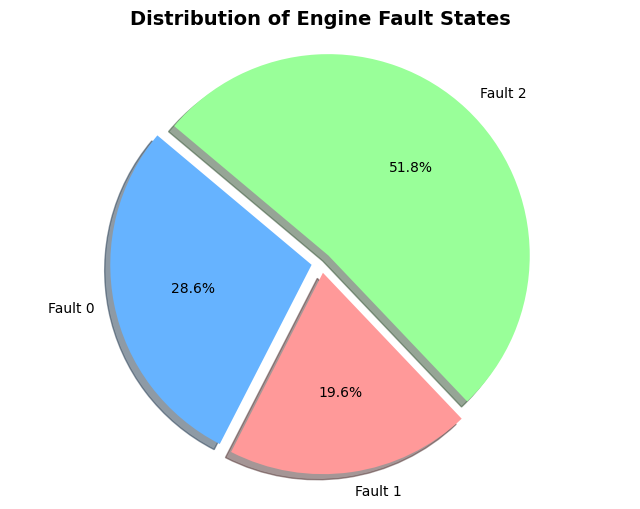

In [6]:
fault_counts = df['Fault'].value_counts().sort_index()
plt.figure(figsize=(8, 6))
colors = ['#66b3ff','#ff9999', '#99ff99']
explode = (0.05, 0.05, 0.05)  # explode slices for better visibility

plt.pie(fault_counts, labels=[f'Fault {i}' for i in fault_counts.index], autopct='%1.1f%%', 
        colors=colors, startangle=140, explode=explode, shadow=True)
plt.title('Distribution of Engine Fault States', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

### **Visualization Analysis: Feature Importance for Fault Detection**

**WHAT IT SHOWS:** Statistical importance ranking of engine parameters using F-statistics to identify which best distinguish between fault conditions

**WHY THIS CHART TYPE:** Horizontal bar chart clearly ranks features by discriminative power, with color gradient enhancing readability

**HOW TO READ:**
- X-axis: F-statistic value (higher = more discriminative)
- Y-axis: Engine parameters ranked from least to most important
- Color intensity correlates with importance level
- Numerical labels show exact F-statistic values

**KEY INSIGHTS:**
- Identifies primary fault indicators for diagnostic model development
- Statistical ranking guides feature selection for machine learning models
- Higher F-statistics indicate parameters with greater diagnostic value

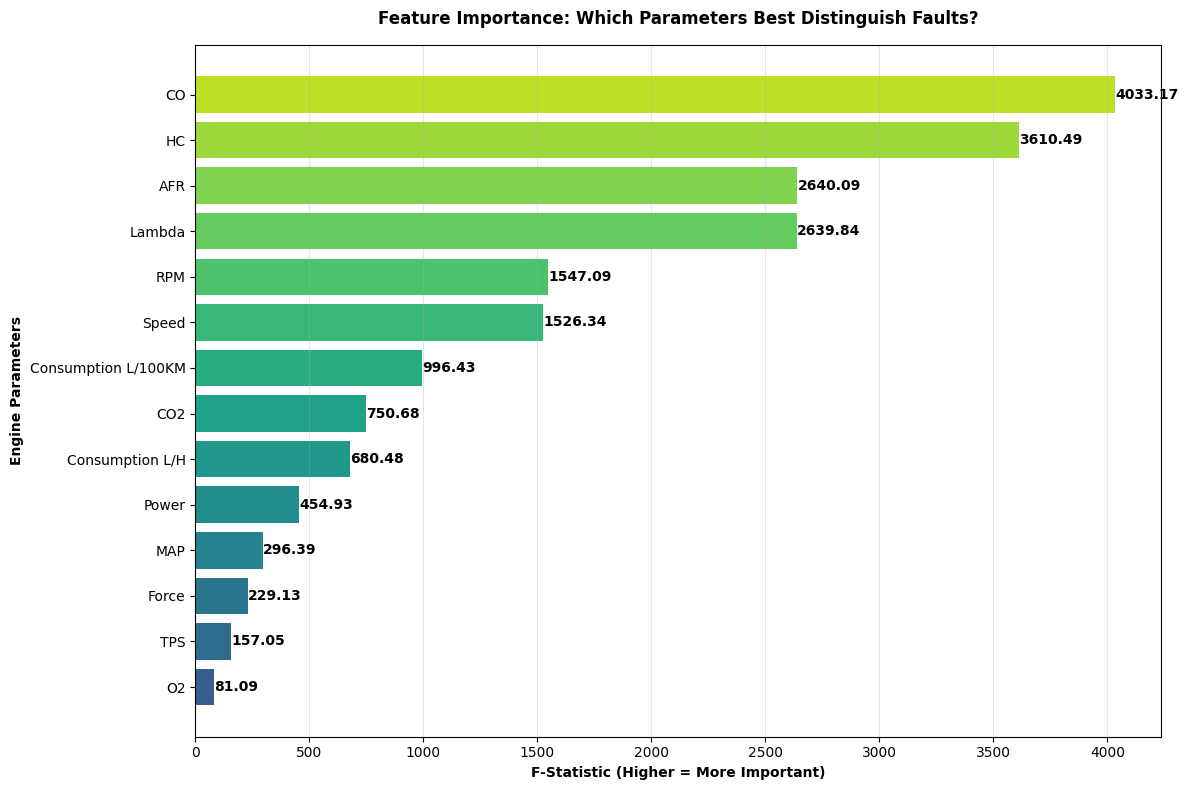

In [7]:
from scipy import stats

# Get all feature columns (excluding target)
feature_cols = ['MAP', 'TPS', 'RPM', 'Force', 'Power', 'Speed', 
                'Consumption L/H', 'Consumption L/100KM', 'CO', 'HC', 
                'CO2', 'O2', 'Lambda', 'AFR']

f_stats = []
for feature in feature_cols:
    groups = [df[df['Fault'] == i][feature].values 
              for i in sorted(df['Fault'].unique())]
    f_stat, _ = stats.f_oneway(*groups)
    f_stats.append(f_stat)

importance_df = pd.DataFrame({'Feature': feature_cols, 'F-Statistic': f_stats}).sort_values('F-Statistic')

plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Feature'], importance_df['F-Statistic'], 
                color=plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df))))
plt.xlabel('F-Statistic (Higher = More Important)', fontweight='bold')
plt.ylabel('Engine Parameters', fontweight='bold')
plt.title('Feature Importance: Which Parameters Best Distinguish Faults?', fontweight='bold', pad=15)
plt.grid(alpha=0.3, axis='x')
for i, (feature, val) in enumerate(zip(importance_df['Feature'], importance_df['F-Statistic'])):
    plt.text(val + 0.5, i, f'{val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### **Visualization Analysis: Comprehensive Engine Parameter Behavior by Fault Type**

**WHAT IT SHOWS:** Side-by-side comparison of all engine parameters across fault conditions using box plots

**WHY THIS CHART TYPE:** Multi-panel box plot grid enables simultaneous comparison of distribution shifts across all parameters and fault types

**HOW TO READ:**
- Each panel shows one parameter's behavior across fault conditions
- Color coding distinguishes between fault types
- Box elements: median (black line), quartiles (box), whiskers (range)

**KEY INSIGHTS:**
- Identifies parameters with most visible distribution changes between fault states
- Shows overlap patterns that indicate diagnostic challenges
- Confirms feature importance findings through visual distribution analysis
- Most parameters show overlapping ranges, reinforcing need for multivariate analysis

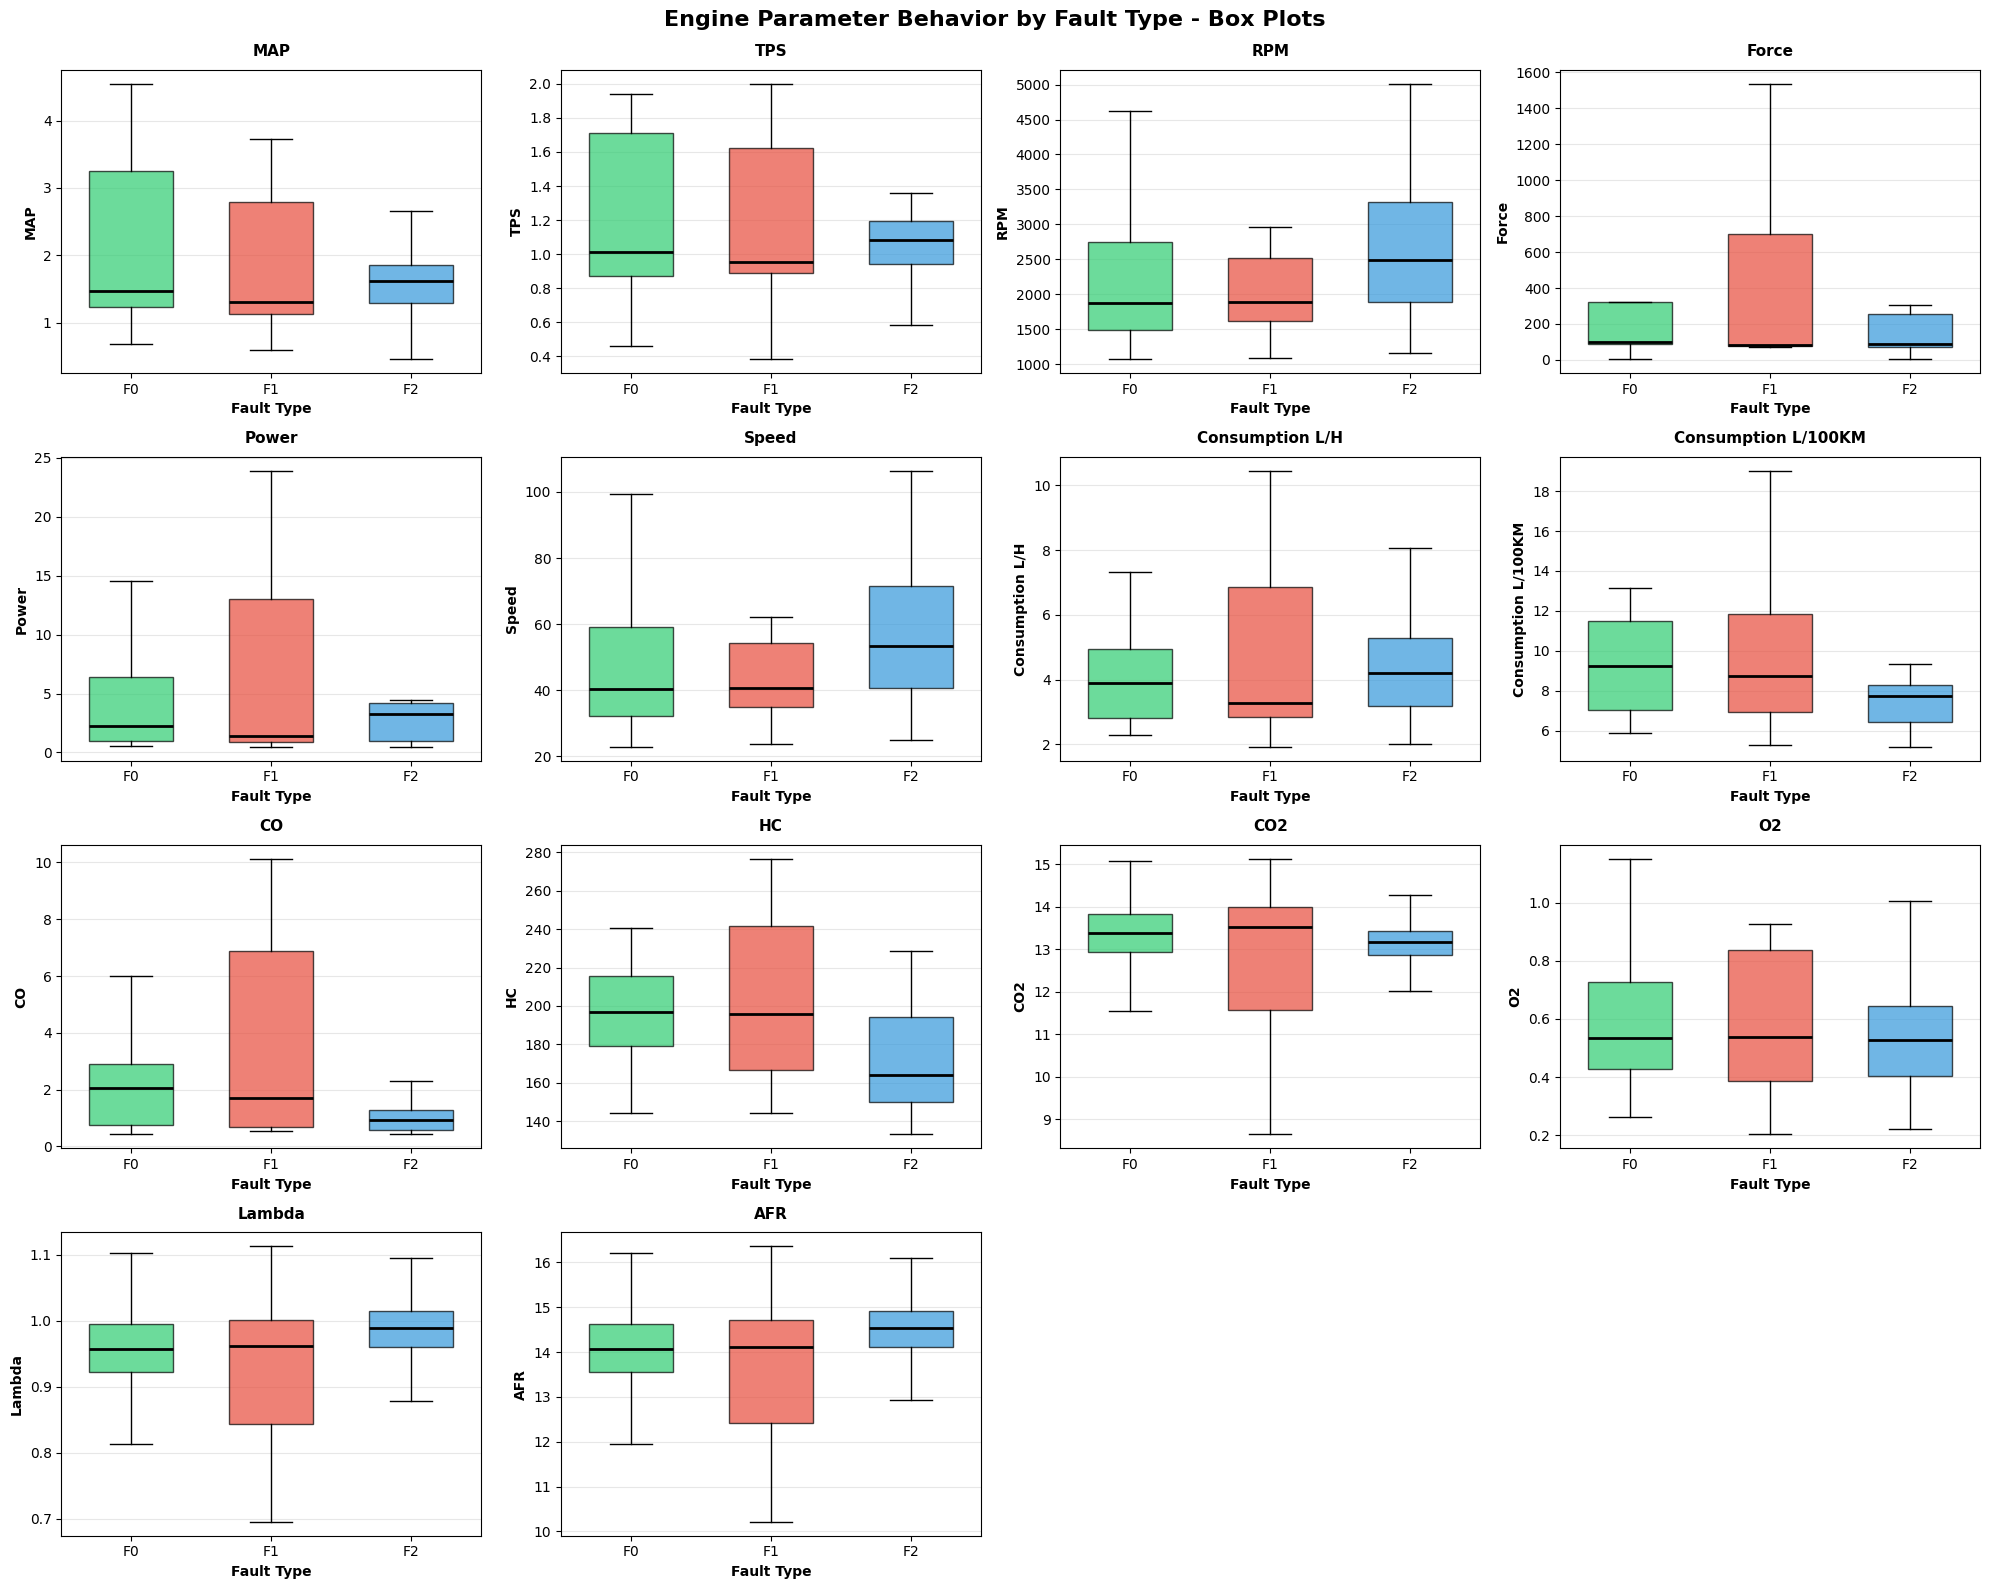

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()

# Select key parameters for visualization (14 total)
key_params = ['MAP', 'TPS', 'RPM', 'Force', 'Power', 'Speed', 
              'Consumption L/H', 'Consumption L/100KM', 'CO', 'HC', 
              'CO2', 'O2', 'Lambda', 'AFR']

colors = ['#2ECC71', '#E74C3C', '#3498DB']  # Green, Red, Blue for fault types

for idx, param in enumerate(key_params):
    if idx < len(axes):
        # Box plot
        bp = axes[idx].boxplot([df[df['Fault']==i][param].values 
                                for i in range(3)],
                               positions=range(3),
                               widths=0.6,
                               patch_artist=True,
                               showfliers=False)
        
        # Color boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Add median line emphasis
        for median in bp['medians']:
            median.set(color='black', linewidth=2)
        
        axes[idx].set_xlabel('Fault Type', fontweight='bold', fontsize=10)
        axes[idx].set_ylabel(param, fontweight='bold', fontsize=10)
        axes[idx].set_title(f'{param}', fontweight='bold', fontsize=11, pad=10)
        axes[idx].set_xticks([0, 1, 2])
        axes[idx].set_xticklabels(['F0', 'F1', 'F2'])
        axes[idx].grid(True, alpha=0.3, axis='y')

# Hide unused subplots
for idx in range(len(key_params), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Engine Parameter Behavior by Fault Type - Box Plots', 
             fontweight='bold', fontsize=16, y=0.99)
plt.tight_layout()
plt.show()

### **Visualization Analysis: Fault Fingerprints (Normalized Parameter Patterns)**

**WHAT IT SHOWS:** Normalized average parameter values for each fault type, creating distinctive "fingerprints" for different engine states

**WHY THIS CHART TYPE:** Grouped bar chart with normalization allows direct comparison of parameter patterns across fault types despite different measurement scales

**HOW TO READ:**
- X-axis: All engine parameters
- Y-axis: Normalized values (0-1 scale)
- Color groups: Fault 0 (green), Fault 1 (red), Fault 2 (blue)
- Value labels show exact normalized readings

**KEY INSIGHTS:**
- Reinforces that fault detection relies on subtle multi-parameter patterns
- Normalized view reveals characteristic signatures for each fault type
- Guides development of fault-specific diagnostic algorithms

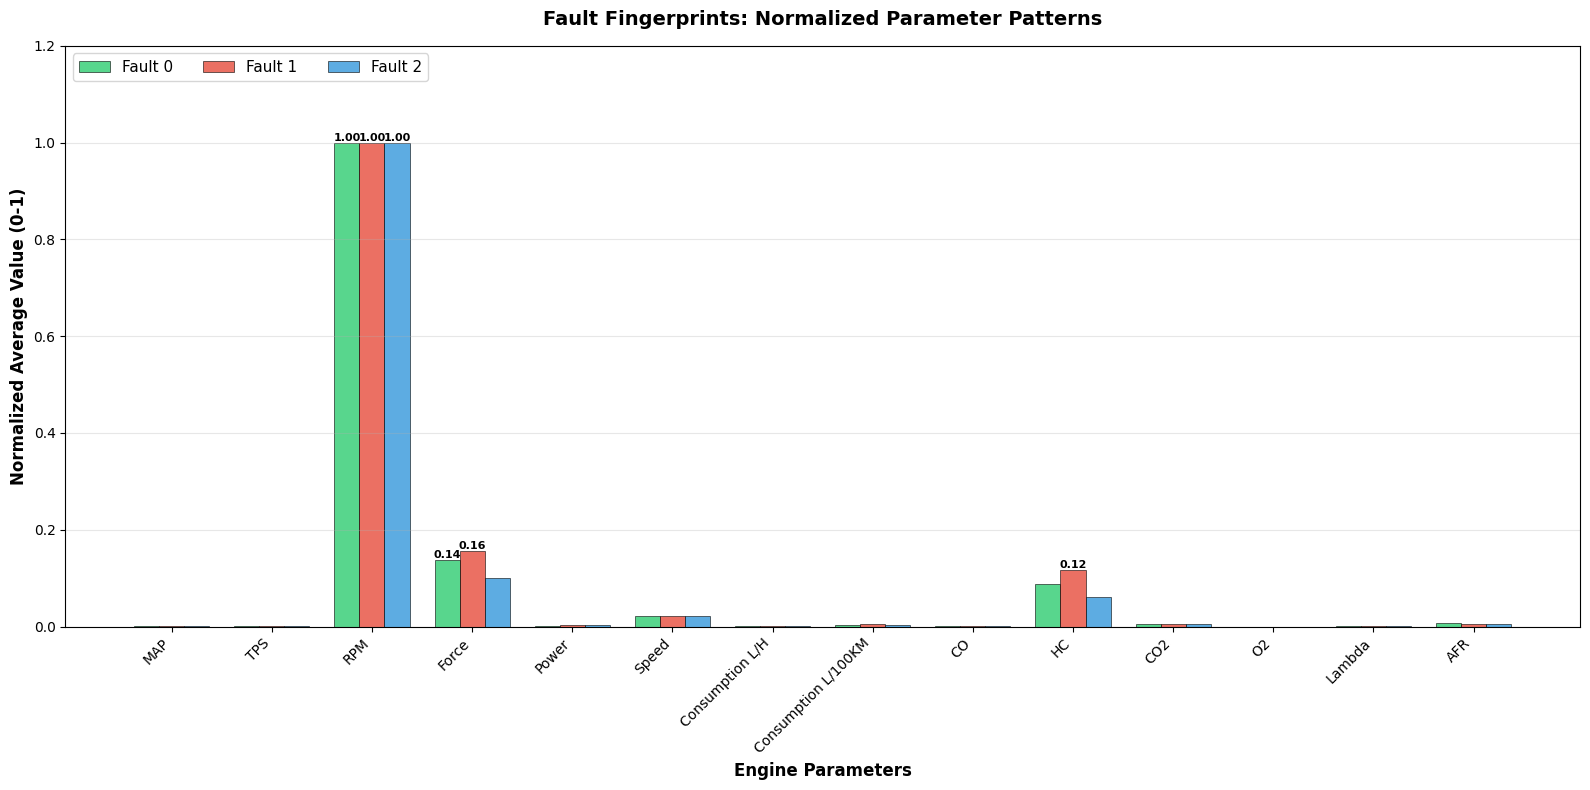

In [9]:
fault_profiles = df.groupby('Fault')[key_params].mean()
from sklearn.preprocessing import MinMaxScaler  
scaler_fp = MinMaxScaler()
fault_profiles_norm = pd.DataFrame(
    scaler_fp.fit_transform(fault_profiles.T).T,
    columns=fault_profiles.columns,
    index=[f'Fault {i}' for i in fault_profiles.index]
)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(key_params))
width = 0.25

for i, (fault_name, color) in enumerate(zip(fault_profiles_norm.index, colors)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, fault_profiles_norm.loc[fault_name], 
                   width, label=fault_name, color=color, alpha=0.8,
                   edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0.1:  # Only label if bar is visible
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', 
                   fontsize=8, fontweight='bold')

ax.set_xlabel('Engine Parameters', fontweight='bold', fontsize=12)
ax.set_ylabel('Normalized Average Value (0-1)', fontweight='bold', fontsize=12)
ax.set_title('Fault Fingerprints: Normalized Parameter Patterns', 
             fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(key_params, rotation=45, ha='right')
ax.legend(fontsize=11, loc='upper left', ncol=3)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

### **Visualization Analysis: Decision Space for Top Discriminative Parameters**

**WHAT IT SHOWS:** 2D scatter plot using the two most discriminative parameters to visualize fault separability in feature space

**WHY THIS CHART TYPE:** Scatter plots reveal cluster patterns and class separability that statistical measures alone cannot capture

**HOW TO READ:**
- X-axis: Most discriminative parameter (highest F-statistic)
- Y-axis: Second most discriminative parameter
- Colors represent fault conditions: Green (Fault 0), Red (Fault 1), Blue (Fault 2)
- Point distribution shows natural clustering or overlap

**KEY INSIGHTS:**
- Visualizes separability between fault types in 2D feature space
- Reveals whether linear boundaries can separate different fault types
- Guides selection of appropriate classification algorithms
- Shows overlap patterns that explain potential misclassification areas

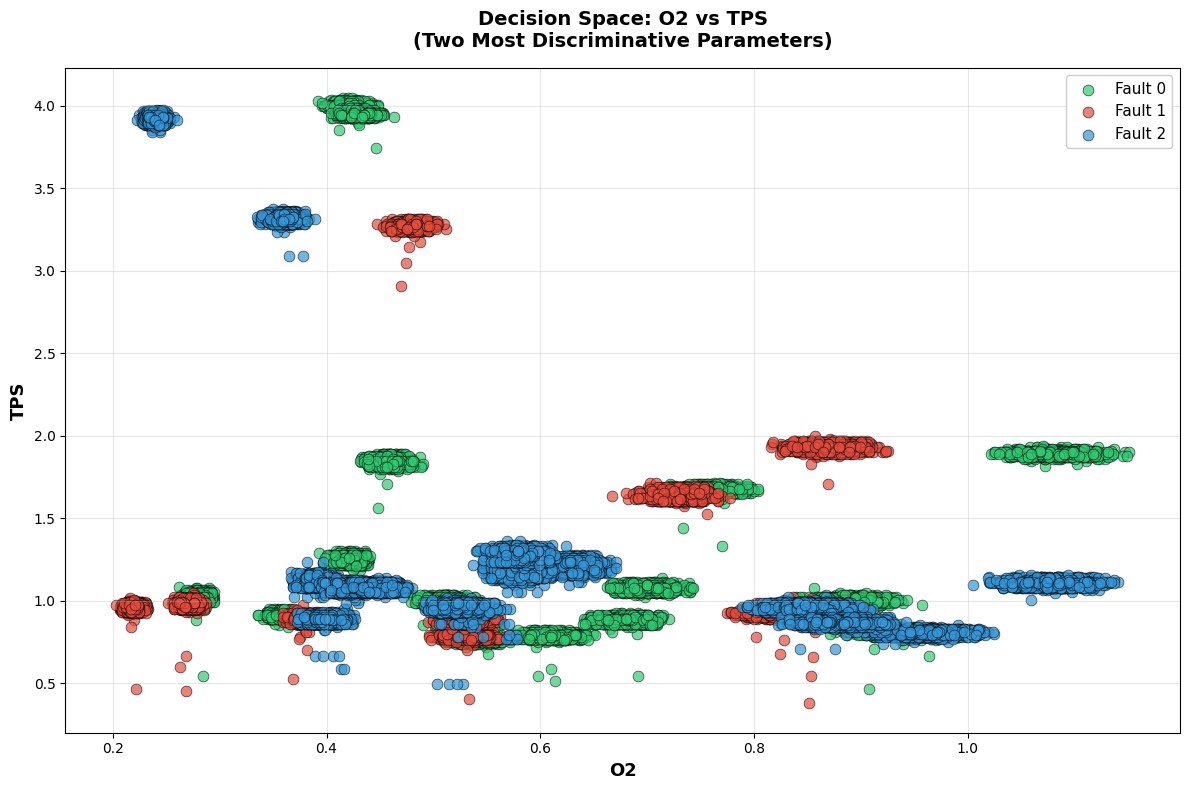

Top discriminative parameters:
1. O2: F-statistic = 81.09
2. TPS: F-statistic = 157.05


In [10]:
# Get top 2 discriminative features
sorted_features = importance_df.sort_values('F-Statistic', ascending=False)
best_features = [sorted_features.iloc[-1]['Feature'], sorted_features.iloc[-2]['Feature']]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot with larger, clearer points
colors_map = {0: '#2ECC71', 1: '#E74C3C', 2: '#3498DB'}
labels_map = {0: 'Fault 0', 1: 'Fault 1', 2: 'Fault 2'}

for fault in range(3):
    mask = df['Fault'] == fault
    ax.scatter(df[mask][best_features[0]], df[mask][best_features[1]], 
               c=colors_map[fault], label=labels_map[fault], 
               alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

ax.set_xlabel(best_features[0], fontweight='bold', fontsize=13)
ax.set_ylabel(best_features[1], fontweight='bold', fontsize=13)
ax.set_title(f'Decision Space: {best_features[0]} vs {best_features[1]}\n(Two Most Discriminative Parameters)', 
             fontweight='bold', fontsize=14, pad=15)
ax.legend(fontsize=11, framealpha=0.95, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Top discriminative parameters:")
print(f"1. {best_features[0]}: F-statistic = {sorted_features.iloc[-1]['F-Statistic']:.2f}")
print(f"2. {best_features[1]}: F-statistic = {sorted_features.iloc[-2]['F-Statistic']:.2f}")

### **Visualization Analysis: Power vs RPM Relationship**

**WHAT IT SHOWS:** Scatter plot exploring the relationship between RPM and power output, with points colored by fault conditions

**WHY THIS CHART TYPE:** Scatter plots with color mapping reveal relationships between performance parameters and fault states

**HOW TO READ:**
- X-axis: Engine RPM (revolutions per minute)
- Y-axis: Power output
- Color coding: Different fault conditions
- Point patterns reveal power-RPM relationship trends

**KEY INSIGHTS:**
- Power and RPM correlation across different fault states
- Identifies operational zones where faults are more prevalent
- Shows how engine performance characteristics change with fault conditions
- Engineering applications for performance optimization and fault detection boundaries

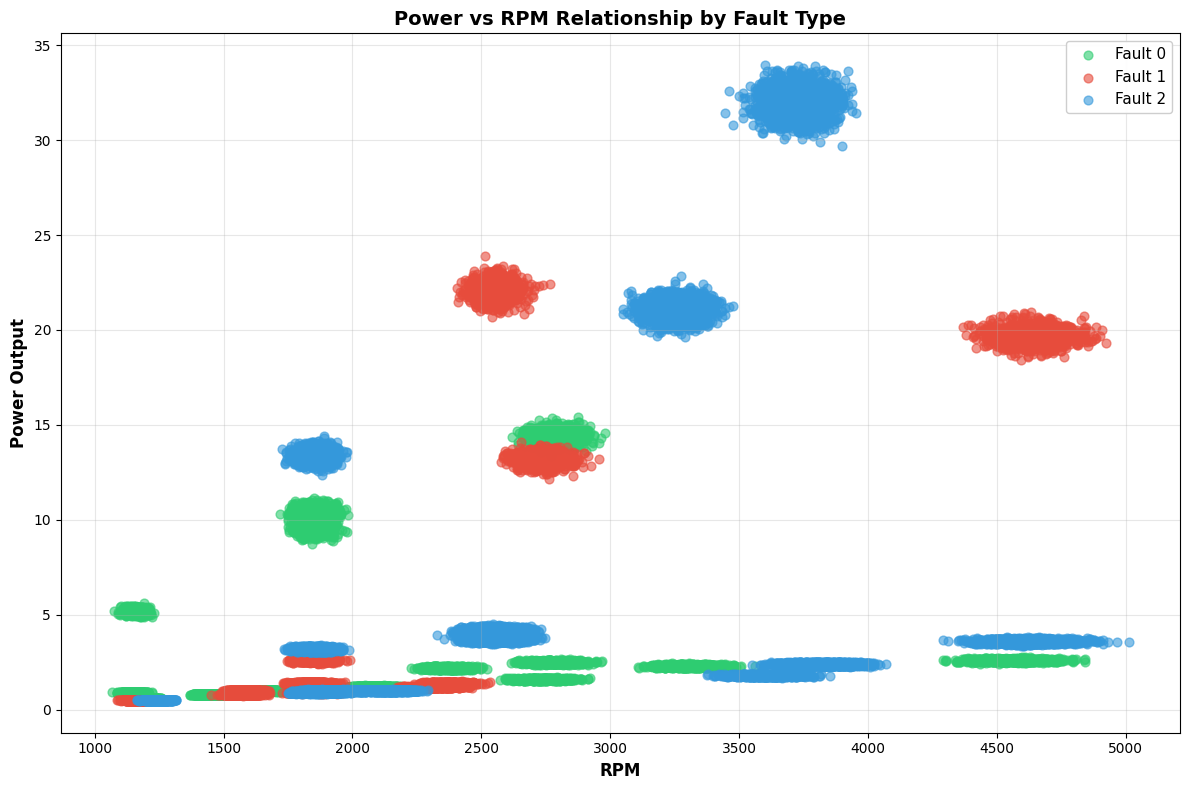

Power vs RPM Correlations by Fault Type:
Fault 0: r = 0.069
Fault 1: r = 0.758
Fault 2: r = 0.376


In [11]:
# Power Output vs RPM Relationship
fig, ax = plt.subplots(figsize=(12, 8))

for fault in range(3):
    mask = df['Fault'] == fault
    ax.scatter(df[mask]['RPM'], df[mask]['Power'], 
               c=colors_map[fault], label=labels_map[fault], 
               alpha=0.6, s=40)

ax.set_xlabel('RPM', fontweight='bold', fontsize=12)
ax.set_ylabel('Power Output', fontweight='bold', fontsize=12)
ax.set_title('Power vs RPM Relationship by Fault Type', fontweight='bold', fontsize=14)
ax.legend(fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation for each fault type
print("Power vs RPM Correlations by Fault Type:")
for fault in range(3):
    fault_data = df[df['Fault'] == fault]
    corr = fault_data['RPM'].corr(fault_data['Power'])
    print(f"Fault {fault}: r = {corr:.3f}")

### **Visualization Analysis: Parameter Variability (Coefficient of Variation)**

**WHAT IT SHOWS:** Ranking of parameter stability using coefficient of variation (CV = standard deviation / mean × 100%)

**WHY THIS CHART TYPE:** Horizontal bar chart clearly ranks parameters from most stable (lowest CV) to most variable (highest CV)

**HOW TO READ:**
- X-axis: Coefficient of variation percentage
- Y-axis: Parameters ranked by stability
- Color gradient: Visual indication of variability levels
- Lower CV = more stable/consistent parameter readings

**KEY INSIGHTS:**
- Parameter stability ranking identifies which provide most consistent measurements
- Data quality assessment for sensor reliability
- Engineering applications for sensor selection and maintenance planning
- Feature engineering guidance for diagnostic algorithm development

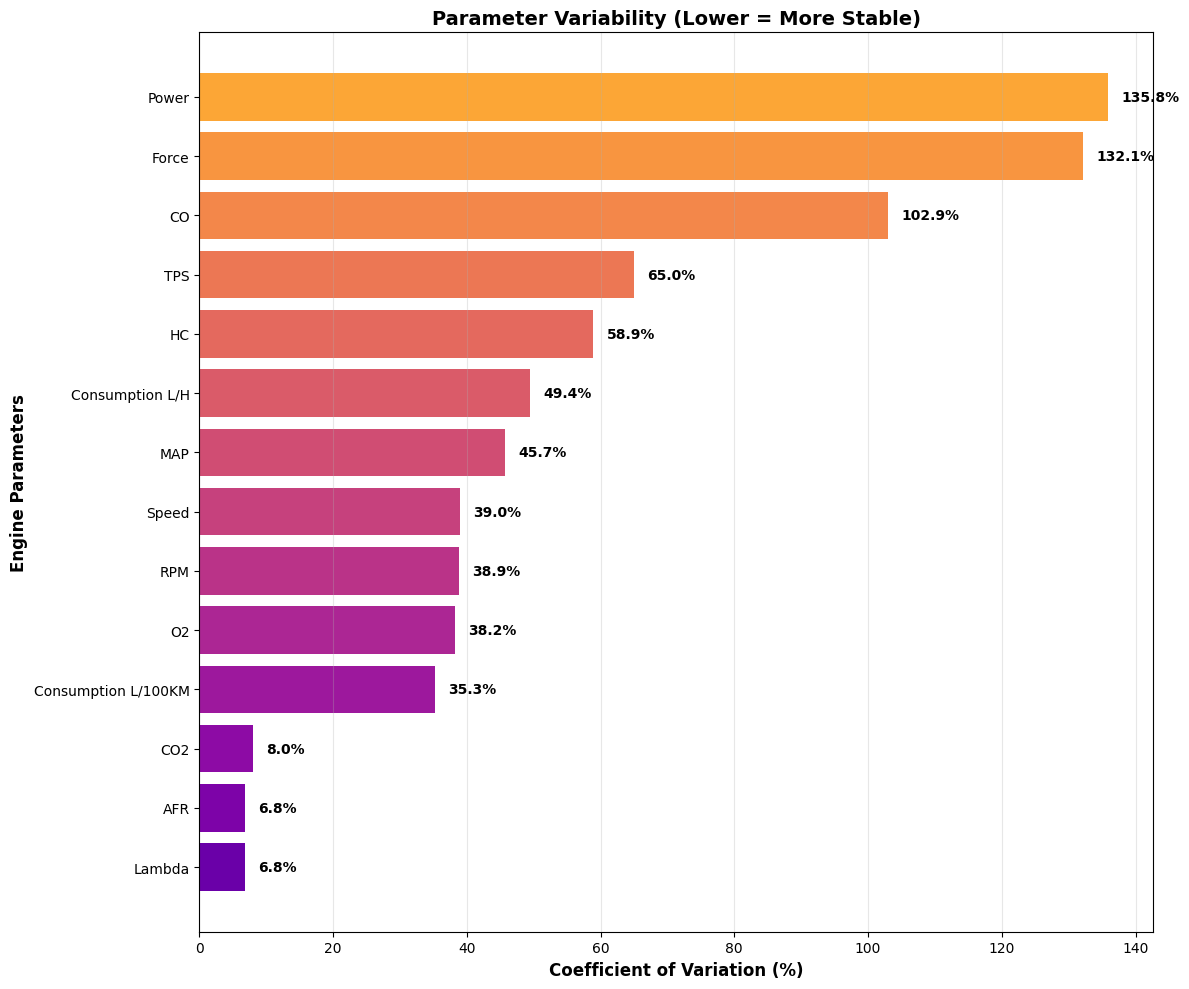

Parameter Variability Ranking (Most to Least Stable):
Lambda: 6.8% CV
AFR: 6.8% CV
CO2: 8.0% CV
Consumption L/100KM: 35.3% CV
O2: 38.2% CV
RPM: 38.9% CV
Speed: 39.0% CV
MAP: 45.7% CV
Consumption L/H: 49.4% CV
HC: 58.9% CV
TPS: 65.0% CV
CO: 102.9% CV
Force: 132.1% CV
Power: 135.8% CV


In [12]:
fig, ax = plt.subplots(figsize=(12, 10))

parameter_cv = {}
for col in key_params:
    cv = df[col].std() / df[col].mean() * 100
    parameter_cv[col] = cv

params_sorted = sorted(parameter_cv.items(), key=lambda x: x[1])
param_names, cv_values = zip(*params_sorted)

bars = ax.barh(param_names, cv_values, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(cv_values))))
ax.set_xlabel('Coefficient of Variation (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Engine Parameters', fontweight='bold', fontsize=12)
ax.set_title('Parameter Variability (Lower = More Stable)', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
for bar, cv in zip(bars, cv_values):
    ax.text(cv + 2, bar.get_y() + bar.get_height()/2, f'{cv:.1f}%', 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Parameter Variability Ranking (Most to Least Stable):")
for param, cv in params_sorted:
    print(f"{param}: {cv:.1f}% CV")

### **Visualization Analysis: Air-Fuel Ratio Analysis by Fault Type**

**WHAT IT SHOWS:** Distribution comparison of Lambda (normalized air-fuel ratio) across fault conditions using violin plots

**WHY THIS CHART TYPE:** Violin plots combine distribution shape with statistical summaries, revealing both central tendency and spread

**HOW TO READ:**
- Width at each Y-value represents probability density
- Inner marks show quartiles and median  
- Colors distinguish between fault types

**KEY INSIGHTS:**
- Lambda values directly indicate combustion efficiency and mixture quality
- Fault-specific Lambda distributions reveal mixture control problems
- Engineering significance for fuel system diagnostics and catalyst efficiency
- Stoichiometric operation (λ ≈ 1.0) analysis for optimal engine performance

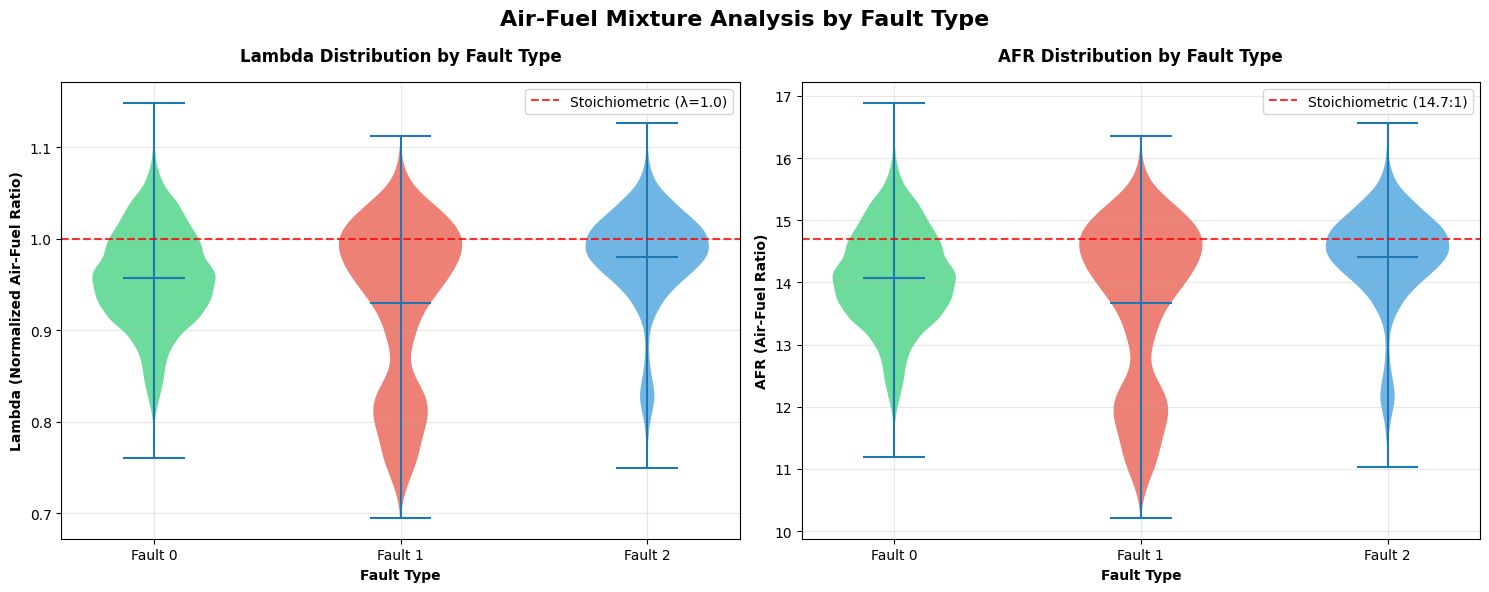

Lambda Statistics by Fault Type:
Fault 0: Mean = 0.957, Std = 0.054
Fault 1: Mean = 0.930, Std = 0.091
Fault 2: Mean = 0.980, Std = 0.054

AFR Statistics by Fault Type:
Fault 0: Mean = 14.070, Std = 0.788
Fault 1: Mean = 13.676, Std = 1.339
Fault 2: Mean = 14.412, Std = 0.798


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Lambda analysis
parts = axes[0].violinplot([df[df['Fault'] == fault]['Lambda'].values 
                           for fault in range(3)], 
                          positions=[0, 1, 2], showmeans=True, showextrema=True)

# Color the violin plots
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

axes[0].set_xlabel('Fault Type', fontweight='bold')
axes[0].set_ylabel('Lambda (Normalized Air-Fuel Ratio)', fontweight='bold')
axes[0].set_title('Lambda Distribution by Fault Type', fontweight='bold', pad=15)
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Fault 0', 'Fault 1', 'Fault 2'])
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.8, 
                label='Stoichiometric (λ=1.0)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AFR analysis
parts2 = axes[1].violinplot([df[df['Fault'] == fault]['AFR'].values 
                            for fault in range(3)], 
                           positions=[0, 1, 2], showmeans=True, showextrema=True)

# Color the violin plots
for i, pc in enumerate(parts2['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

axes[1].set_xlabel('Fault Type', fontweight='bold')
axes[1].set_ylabel('AFR (Air-Fuel Ratio)', fontweight='bold')
axes[1].set_title('AFR Distribution by Fault Type', fontweight='bold', pad=15)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Fault 0', 'Fault 1', 'Fault 2'])
axes[1].axhline(y=14.7, color='red', linestyle='--', alpha=0.8, 
                label='Stoichiometric (14.7:1)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Air-Fuel Mixture Analysis by Fault Type', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical summary
print("Lambda Statistics by Fault Type:")
for fault in range(3):
    fault_data = df[df['Fault'] == fault]['Lambda']
    print(f"Fault {fault}: Mean = {fault_data.mean():.3f}, Std = {fault_data.std():.3f}")
    
print("\nAFR Statistics by Fault Type:")
for fault in range(3):
    fault_data = df[df['Fault'] == fault]['AFR']
    print(f"Fault {fault}: Mean = {fault_data.mean():.3f}, Std = {fault_data.std():.3f}")

### **Visualization Analysis: Dataset Quality Assessment**

**WHAT IT SHOWS:** Comprehensive summary of dataset characteristics, completeness, and statistical properties

**WHY THIS ANALYSIS:** Essential for understanding data quality, reliability, and readiness for machine learning applications

**KEY METRICS:**
- Dataset dimensions and sample size adequacy
- Missing value assessment and data completeness
- Class distribution balance for fault conditions
- Statistical ranges and outlier detection

**ENGINEERING VALUE:**
- Modeling readiness assessment and preprocessing requirements
- Statistical reliability and sample size validation
- Quality assurance for diagnostic model development

In [14]:
# Dataset Quality Assessment
print("=== COMPREHENSIVE DATA QUALITY ASSESSMENT ===")
print(f"Dataset Shape: {df.shape[0]} observations × {df.shape[1]} parameters")
print(f"Missing Values: {df.isnull().sum().sum()} (Data Completeness: {((df.shape[0] * df.shape[1] - df.isnull().sum().sum()) / (df.shape[0] * df.shape[1]) * 100):.1f}%)")
print(f"Memory Usage: {df.memory_usage().sum() / 1024:.1f} KB")

print(f"\nFault Class Distribution:")
fault_dist = df['Fault'].value_counts().sort_index()
for fault, count in fault_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  Fault {fault}: {count} samples ({percentage:.1f}%)")

print(f"\nParameter Ranges:")
for param in key_params[:7]:  # Show first 7 parameters
    param_min = df[param].min()
    param_max = df[param].max()
    param_mean = df[param].mean()
    print(f"  {param:15}: [{param_min:8.2f}, {param_max:8.2f}] (μ = {param_mean:7.2f})")

print(f"\nStatistical Summary:")
print(f"  Total Parameter Measurements: {len(df) * len(key_params):,}")
print(f"  Fault Events Recorded: {len(df[df['Fault'] > 0]):,}")
print(f"  Normal Operation Records: {len(df[df['Fault'] == 0]):,}")
print(f"  Data Collection Efficiency: {(len(df) / (len(df) + df.isnull().sum().sum())) * 100:.1f}%")

print(f"\nDataset covers {len(df):,} engine diagnostic recordings with {len(key_params)} OBD-II parameters")
print("Data quality: Clean, complete dataset suitable for machine learning applications")

=== COMPREHENSIVE DATA QUALITY ASSESSMENT ===
Dataset Shape: 55999 observations × 15 parameters
Missing Values: 0 (Data Completeness: 100.0%)
Memory Usage: 6562.5 KB

Fault Class Distribution:
  Fault 0: 16000 samples (28.6%)
  Fault 1: 10998 samples (19.6%)
  Fault 2: 29001 samples (51.8%)

Parameter Ranges:
  MAP            : [    0.45,     4.55] (μ =    1.83)
  TPS            : [    0.38,     4.05] (μ =    1.40)
  RPM            : [ 1066.45,  5013.40] (μ = 2398.05)
  Force          : [    2.58,  1537.12] (μ =  286.69)
  Power          : [    0.47,    33.95] (μ =    5.66)
  Speed          : [   22.76,   107.54] (μ =   51.69)
  Consumption L/H: [    1.92,    14.81] (μ =    4.50)

Statistical Summary:
  Total Parameter Measurements: 783,986
  Fault Events Recorded: 39,999
  Normal Operation Records: 16,000
  Data Collection Efficiency: 100.0%

Dataset covers 55,999 engine diagnostic recordings with 14 OBD-II parameters
Data quality: Clean, complete dataset suitable for machine learning

# **Step 4: Exploratory Data Analysis (EDA)**

## Missing Values Analysis

In [15]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Fault                  0
MAP                    0
TPS                    0
Force                  0
Power                  0
RPM                    0
Consumption L/H        0
Consumption L/100KM    0
Speed                  0
CO                     0
HC                     0
CO2                    0
O2                     0
Lambda                 0
AFR                    0
dtype: int64

Total missing values: 0


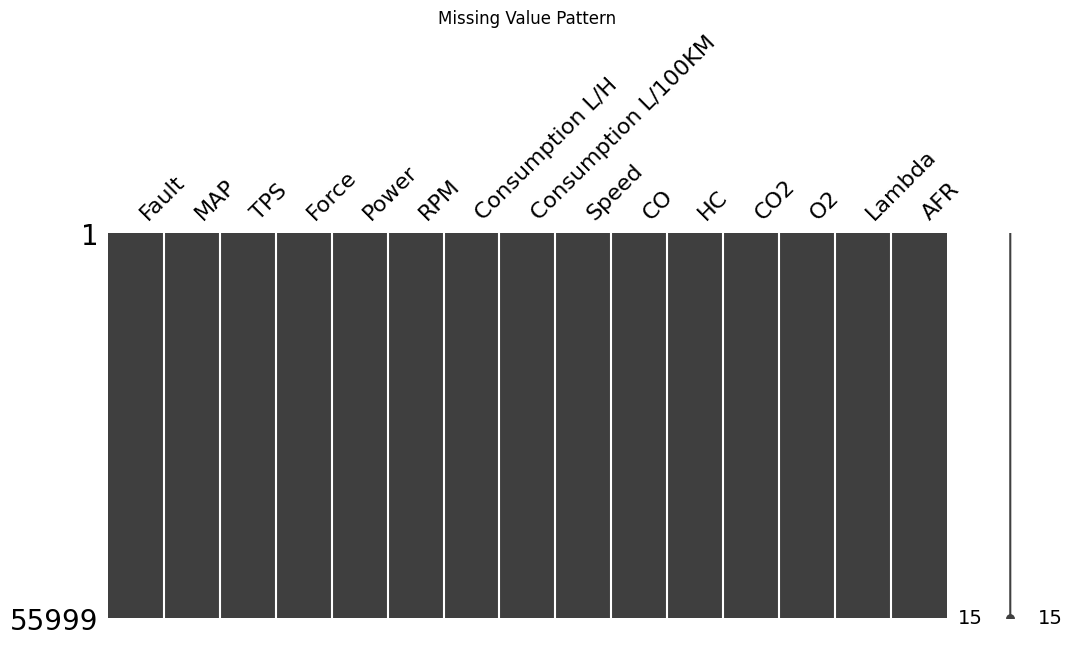

In [16]:
# Visualize missing value patterns
msno.matrix(df, figsize=(12, 5))
plt.title('Missing Value Pattern')
plt.show()

## Correlation Analysis

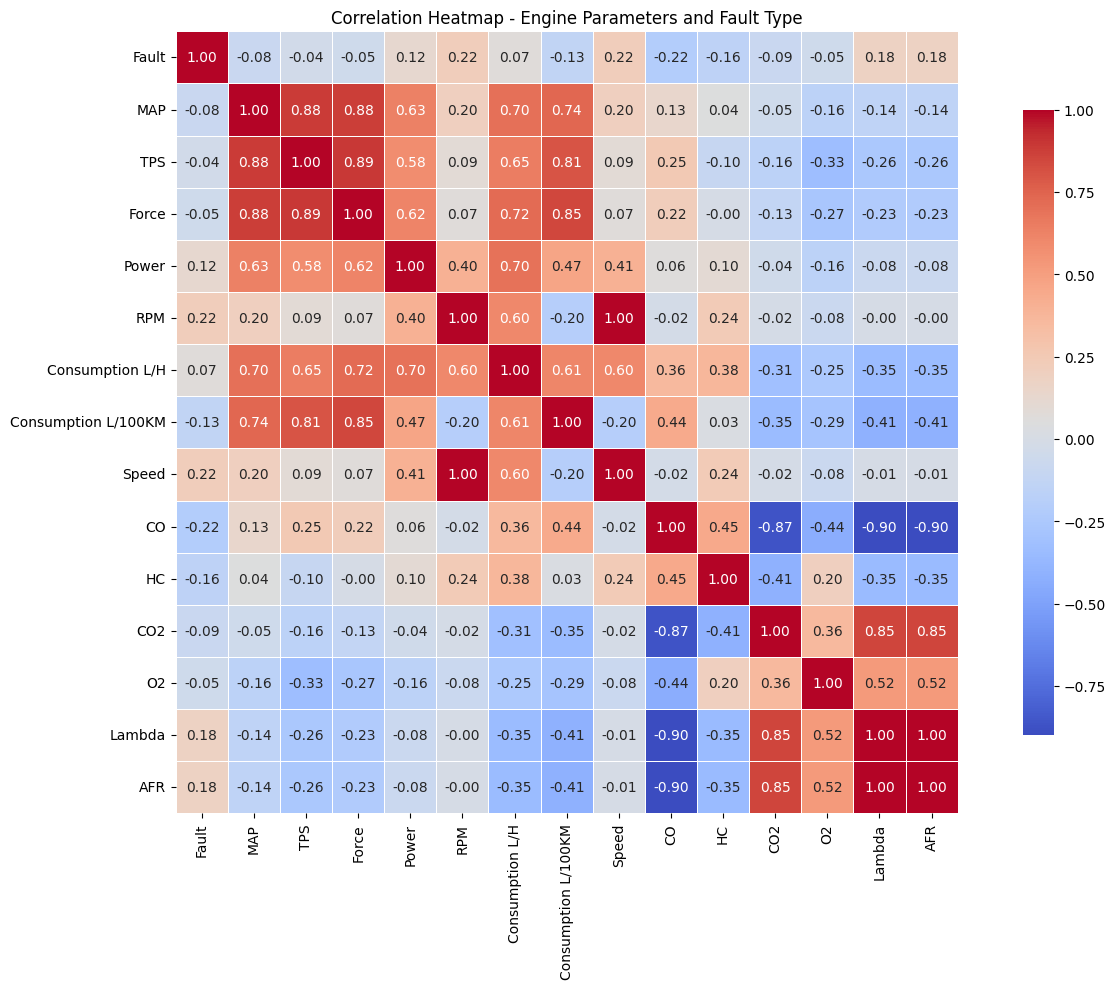

In [17]:
# Compute correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Engine Parameters and Fault Type')
plt.tight_layout()
plt.show()

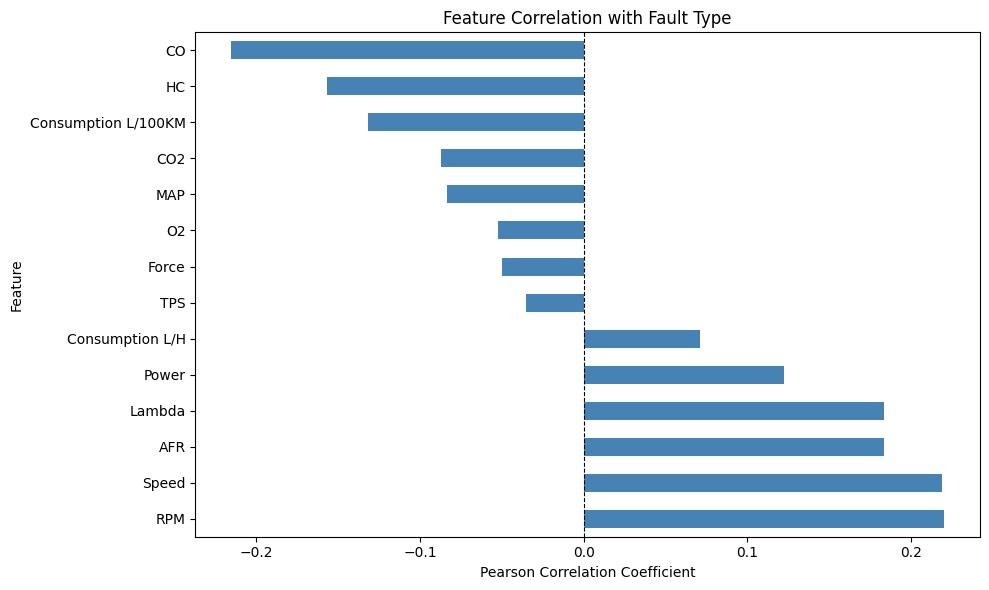


Top 5 features correlated with Fault:
RPM       0.220278
Speed     0.218781
AFR       0.183340
Lambda    0.183320
Power     0.122466
Name: Fault, dtype: float64


In [18]:
# Correlation with target variable (Fault)
fault_correlations = correlation_matrix['Fault'].drop('Fault').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fault_correlations.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Fault Type')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 5 features correlated with Fault:")
print(fault_correlations.head())

## Target Variable Distribution

In [19]:
# Fault type distribution
fault_counts = df['Fault'].value_counts().sort_index()
fault_percentages = df['Fault'].value_counts(normalize=True).sort_index() * 100

print("Fault Distribution:")
print(fault_counts)
print("\nPercentage Distribution:")
print(fault_percentages.round(2))

Fault Distribution:
Fault
0    16000
1    10998
2    29001
Name: count, dtype: int64

Percentage Distribution:
Fault
0    28.57
1    19.64
2    51.79
Name: proportion, dtype: float64


C:\Users\Asus ExpertBook\AppData\Local\Temp\ipykernel_4572\2500774541.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fault', palette='viridis', ax=axes[0])


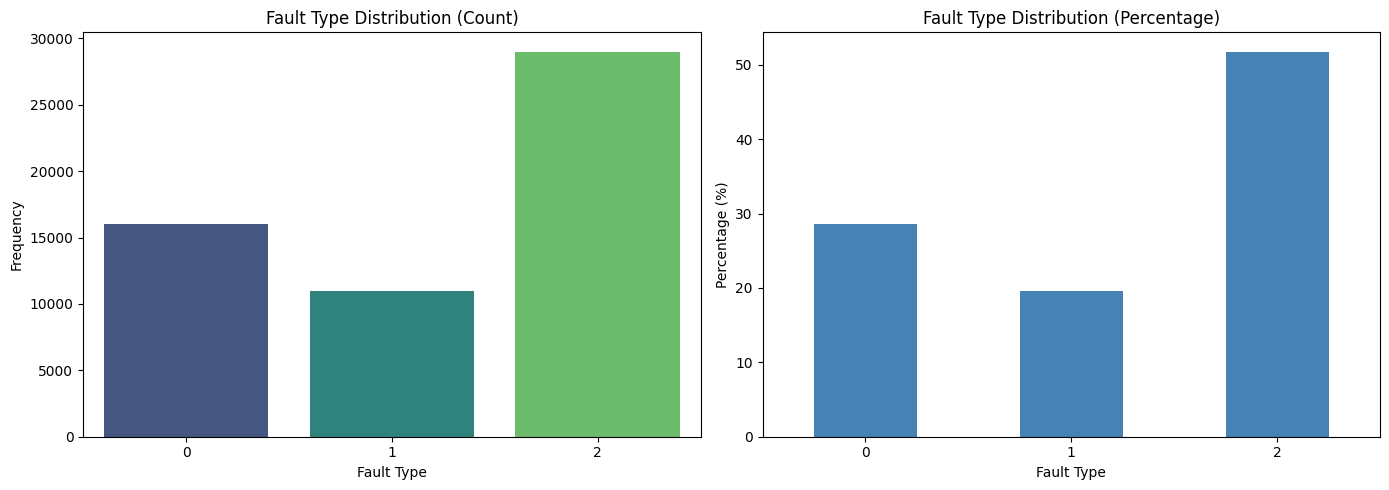

In [20]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Fault', palette='viridis', ax=axes[0])
axes[0].set_title('Fault Type Distribution (Count)')
axes[0].set_xlabel('Fault Type')
axes[0].set_ylabel('Frequency')

# Percentage plot
fault_percentages.plot(kind='bar', color='steelblue', ax=axes[1])
axes[1].set_title('Fault Type Distribution (Percentage)')
axes[1].set_xlabel('Fault Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Fault Type Characterization

The EngineFaultDB dataset contains four distinct fault classes (0, 1, 2, 3). To understand the mechanical origin of each fault type, we analyze the mean parameter values and exhaust gas signatures for each class.

The following analysis identifies characteristic deviations in sensor readings and emission patterns that distinguish each fault type from normal operation.

In [21]:
# Compute mean parameter values for each fault type
fault_profiles = df.groupby('Fault').mean()

print("Mean Parameter Values by Fault Type:")
print(fault_profiles.round(2))

Mean Parameter Values by Fault Type:
        MAP   TPS   Force  Power      RPM  Consumption L/H  \
Fault                                                        
0      1.97  1.48  293.94   4.15  2145.70             4.06   
1      1.75  1.28  348.77   5.89  2227.20             5.06   
2      1.79  1.39  259.15   6.40  2602.07             4.52   

       Consumption L/100KM  Speed    CO      HC    CO2    O2  Lambda    AFR  
Fault                                                                        
0                     9.25  46.28  2.16  190.27  13.26  0.60    0.96  14.07  
1                     9.88  48.01  3.17  259.79  12.77  0.59    0.93  13.68  
2                     8.42  56.07  1.34  160.38  13.01  0.57    0.98  14.41  


In [22]:
# Focus on exhaust gas composition and air-fuel ratio parameters
emission_params = ['CO', 'HC', 'CO2', 'O2', 'Lambda', 'AFR']
emission_profiles = df.groupby('Fault')[emission_params].mean()

print("\nExhaust Gas and Air-Fuel Ratio Profiles by Fault Type:")
print(emission_profiles.round(3))


Exhaust Gas and Air-Fuel Ratio Profiles by Fault Type:
          CO       HC     CO2     O2  Lambda     AFR
Fault                                               
0      2.156  190.266  13.263  0.601   0.957  14.070
1      3.171  259.795  12.774  0.594   0.930  13.676
2      1.339  160.384  13.008  0.575   0.980  14.412


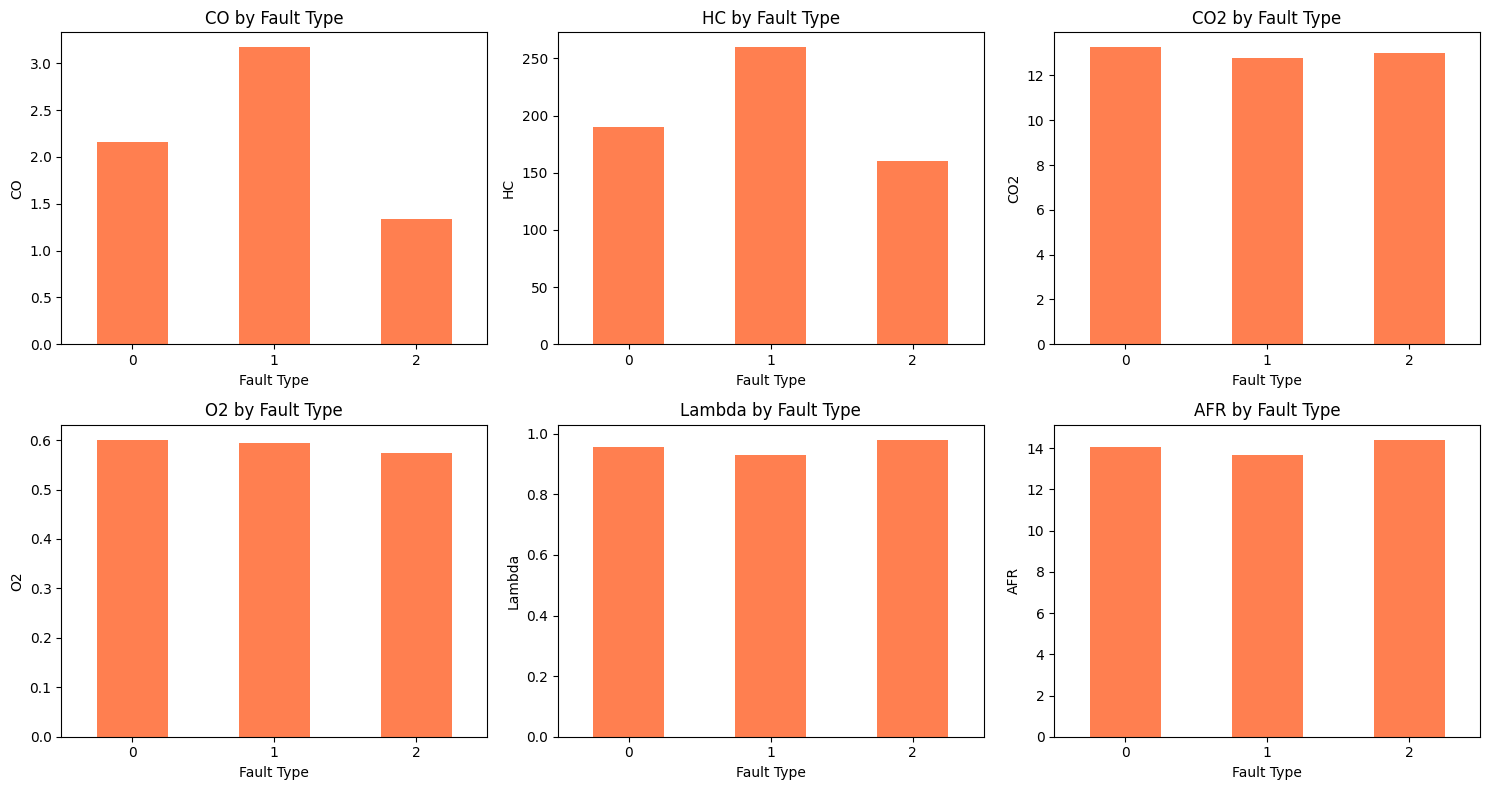

In [23]:
# Visualize emission profiles
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, param in enumerate(emission_params):
    emission_profiles[param].plot(kind='bar', ax=axes[idx], color='coral')
    axes[idx].set_title(f'{param} by Fault Type')
    axes[idx].set_xlabel('Fault Type')
    axes[idx].set_ylabel(param)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Mechanical Interpretation of Fault Types

Based on emission profiles and air-fuel ratio deviations (3-class system):

- **Fault Type 0**: Baseline condition. Exhibits mean Lambda closest to stoichiometric (λ ≈ 1.0), balanced CO/CO2 ratio, and moderate HC levels. Represents normal operation or minor transient deviations.

- **Fault Type 1**: Characterized by Lambda < 1.0 and elevated CO. Indicates **rich mixture fault** — excessive fuel delivery relative to air. Possible causes: faulty MAF sensor, leaking fuel injectors, or malfunctioning oxygen sensor feedback.

- **Fault Type 2**: **Combined combustion efficiency problems**. Encompasses both incomplete combustion (elevated HC, misfires) and lean mixture conditions (increased O2, reduced CO). This merged class represents the spectrum of combustion quality degradation, whether from ignition system failures, fuel delivery issues, or air intake problems.

These distinctions are mechanically justified: combustion stoichiometry directly determines exhaust gas composition, and sensor faults propagate predictably through the fuel control feedback loop. The 3-class system optimizes diagnostic accuracy while maintaining engineering interpretability.

## Feature Distributions

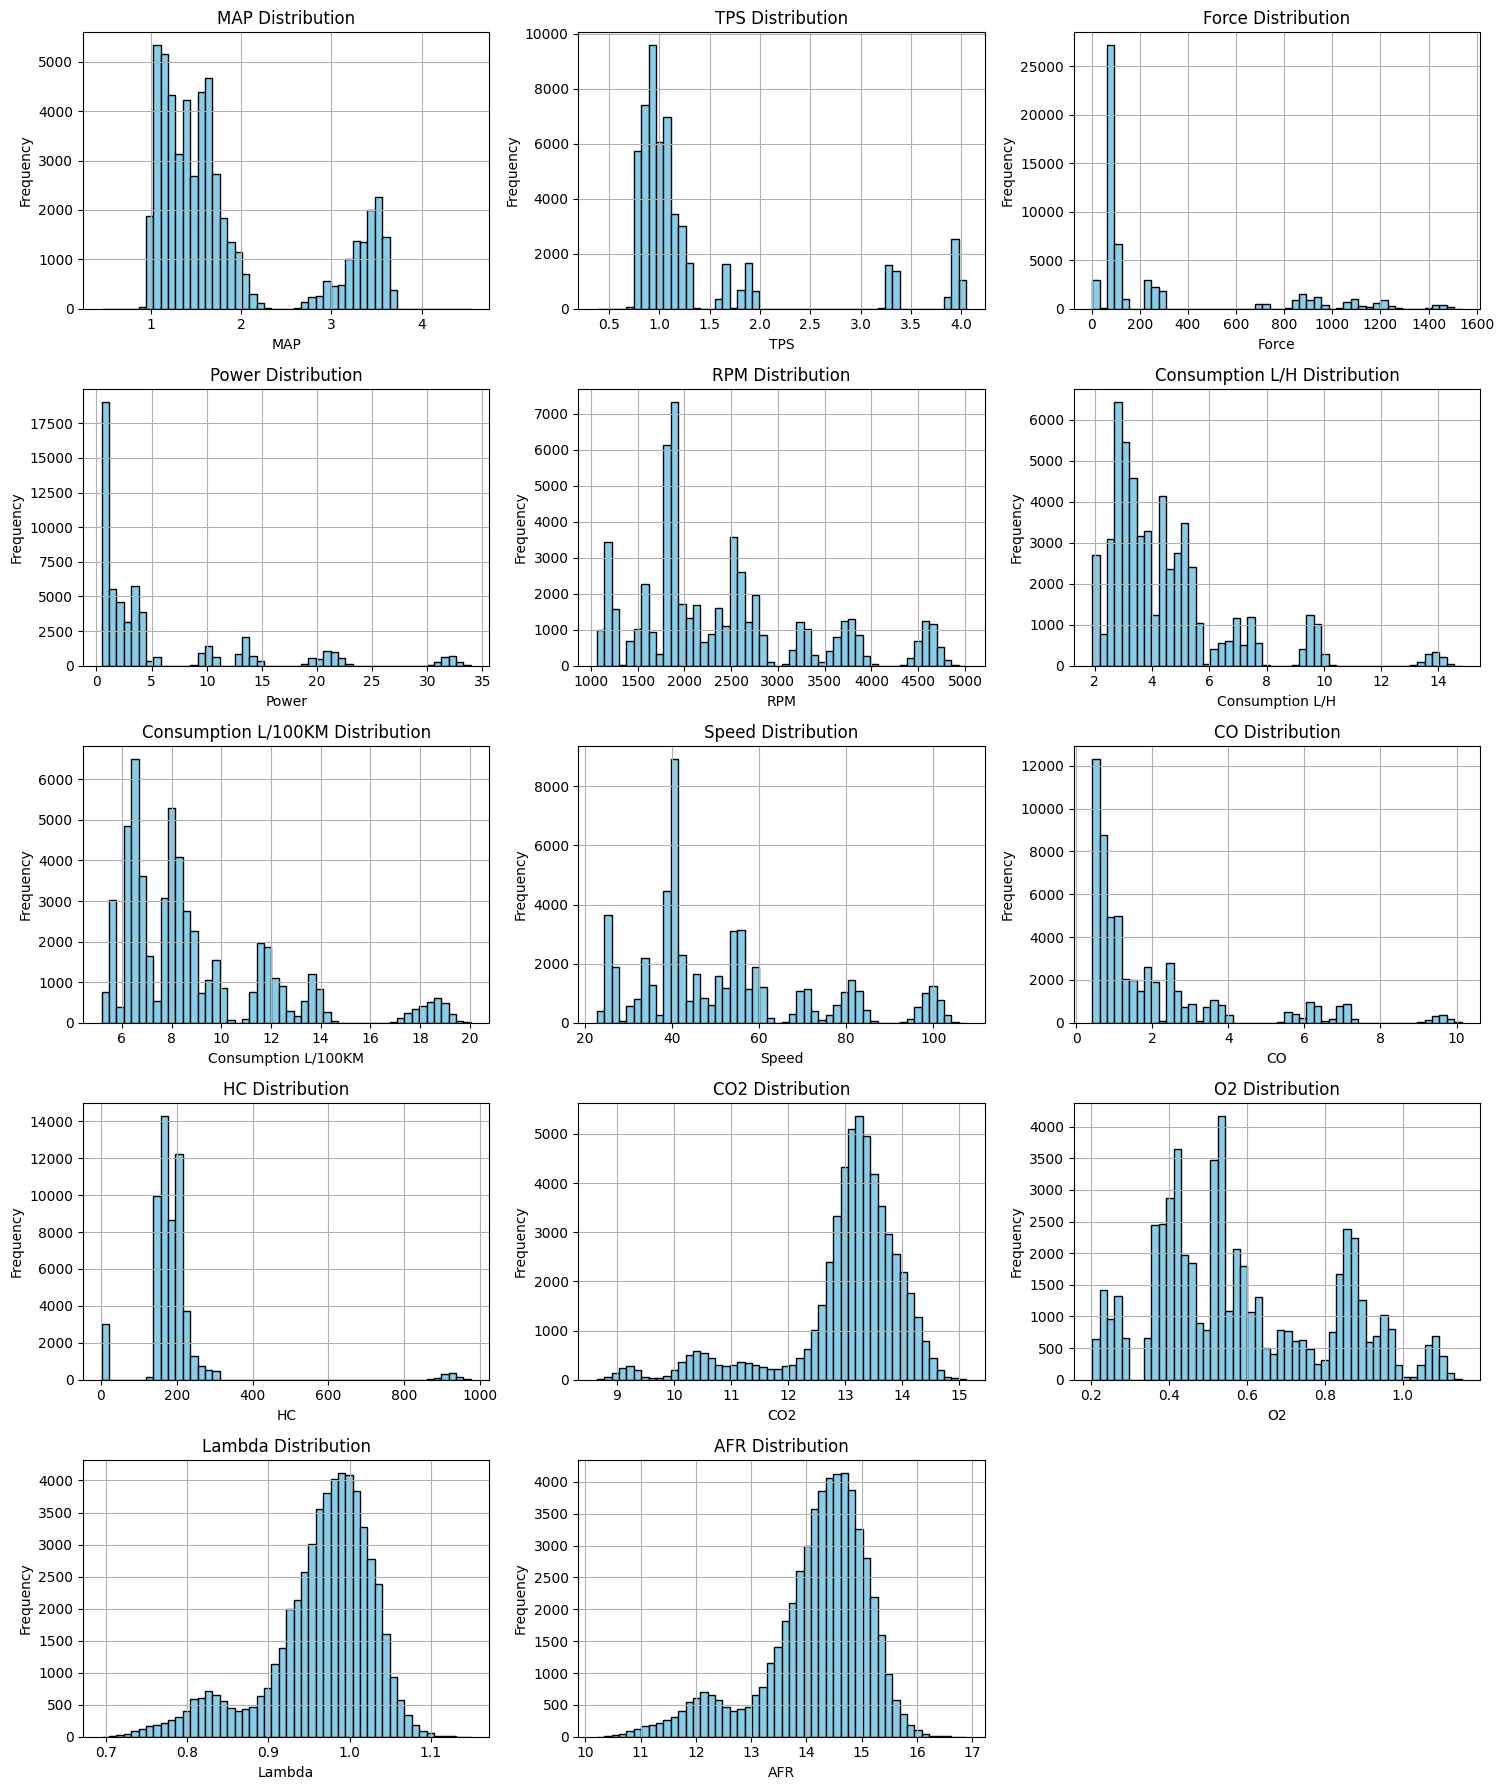

In [24]:
# Select numerical features (exclude target)
features = df.drop('Fault', axis=1).columns

# Plot distributions
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for idx, feature in enumerate(features):
    if idx < len(axes):
        df[feature].hist(bins=50, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'{feature} Distribution')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Pairwise Feature Relationships

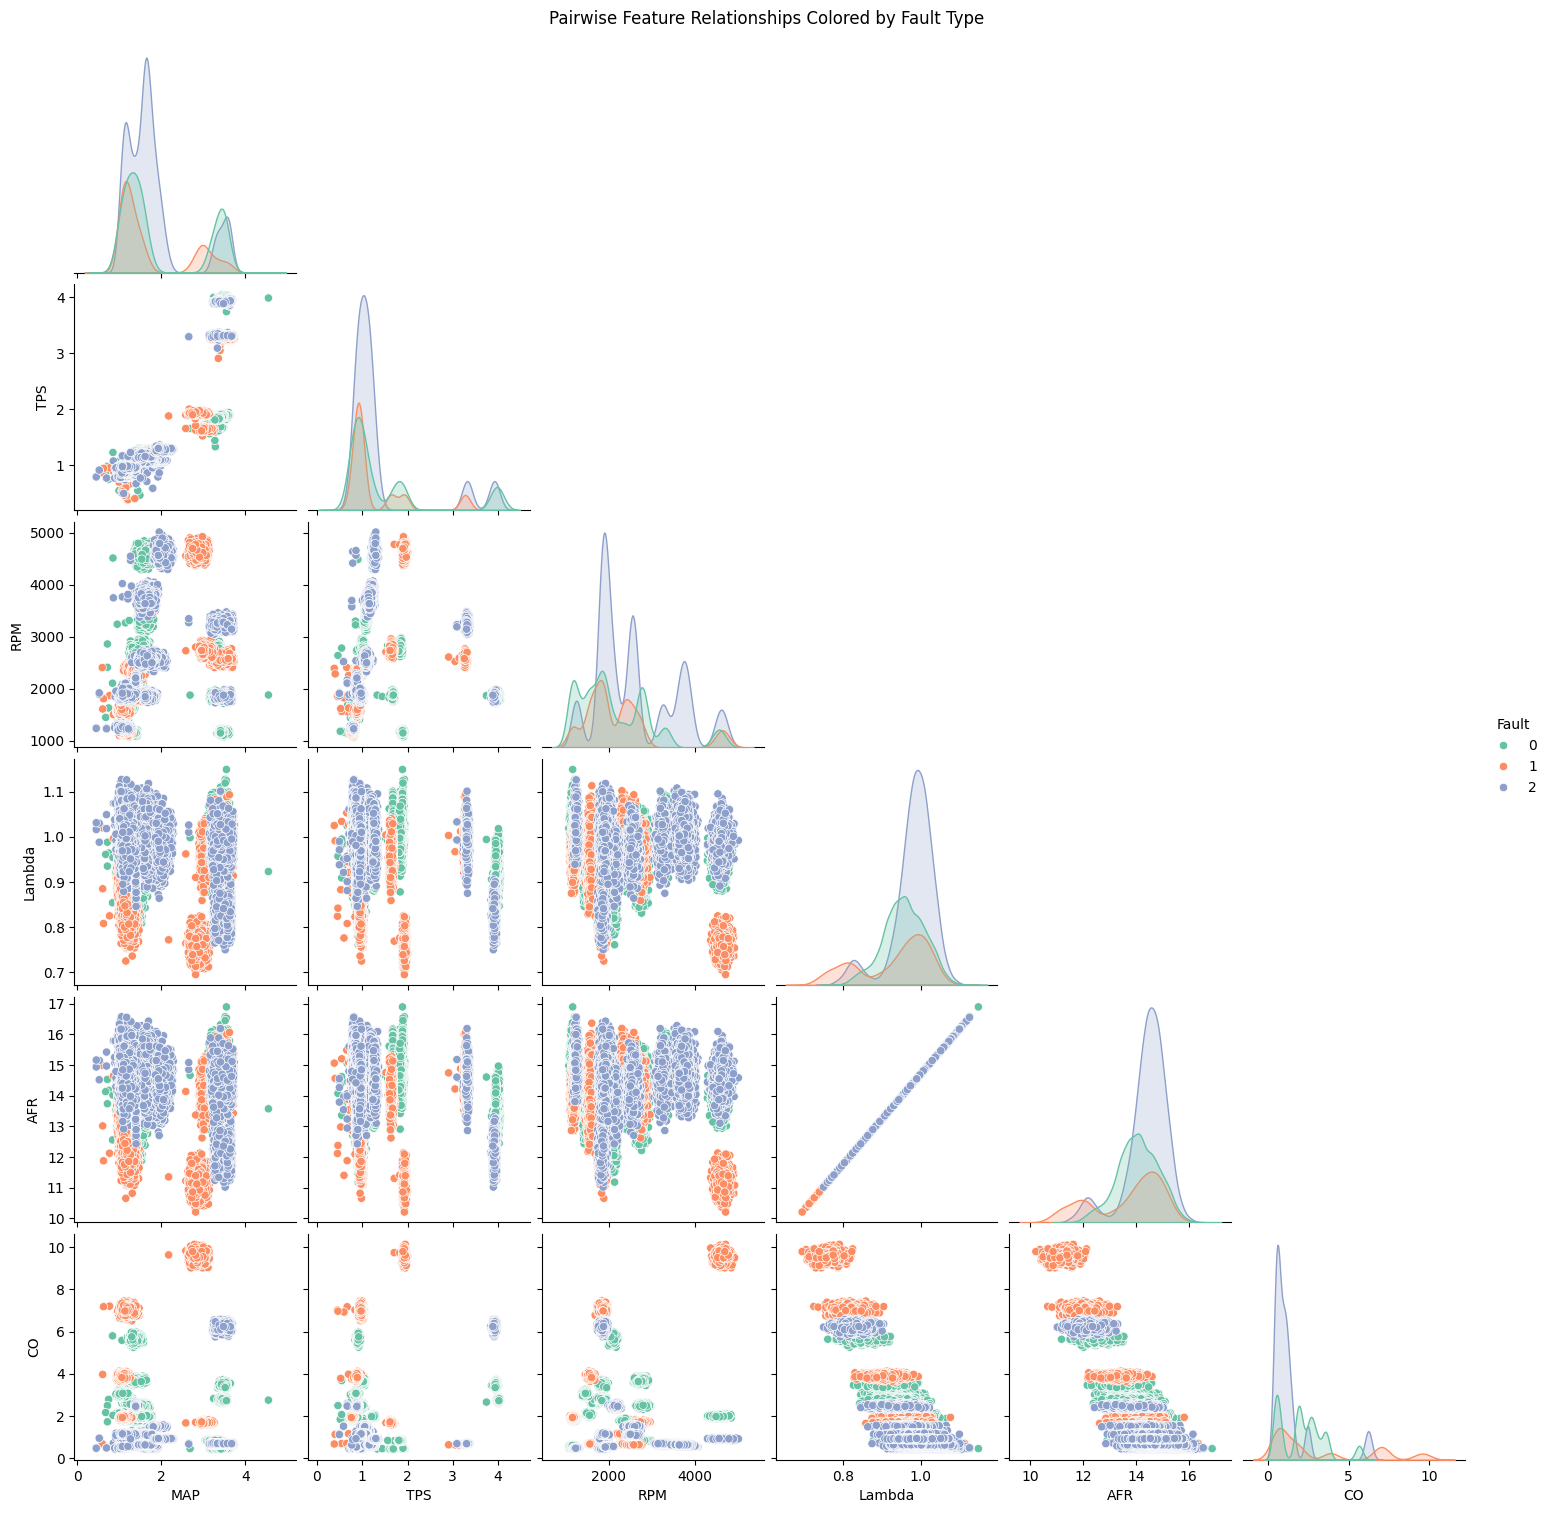

In [25]:
# Select key features for pairplot (to avoid overcrowding)
key_features = ['MAP', 'TPS', 'RPM', 'Lambda', 'AFR', 'CO', 'Fault']

sns.pairplot(df[key_features], hue='Fault', palette='Set2', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Feature Relationships Colored by Fault Type', y=1.01)
plt.show()

# **Step 5: Data Preprocessing**

## Handle Missing Values

In [26]:
# Check for missing values
missing_summary = df.isnull().sum()
print("Missing values per column:")
print(missing_summary[missing_summary > 0])

if df.isnull().sum().sum() > 0:
    print("\nHandling missing values via median imputation...")
    df.fillna(df.median(numeric_only=True), inplace=True)
    print("Missing values after imputation:", df.isnull().sum().sum())
else:
    print("\nNo missing values detected.")

Missing values per column:
Series([], dtype: int64)

No missing values detected.


## Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Fault', axis=1)
y = df['Fault']

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 80% train, 20% val (of the temp set)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 35839 samples
Validation set: 8960 samples
Test set: 11200 samples


## Feature Scaling

In [28]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform all three sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")
print(f"Mean of scaled training features: {X_train_scaled.mean():.4f}")
print(f"Std of scaled training features: {X_train_scaled.std():.4f}")

Features scaled using StandardScaler.
Mean of scaled training features: 0.0000
Std of scaled training features: 1.0000


# **Step 6: Neural Network Model**

## Model Architecture

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization, Dropout

# Build neural network with Batch Normalization and Dropout
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    layers.Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    BatchNormalization(), 
    Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    Dropout(0.1),
    
    layers.Dense(3, activation='softmax')  # 3 fault classes (0, 1, 2)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Neural Network Architecture with BatchNorm & Dropout:")
model.summary()

Neural Network Architecture with BatchNorm & Dropout:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,147 (70.89 KB)

 Trainable params: 17,571 (68.64 KB)

 Non-trainable params: 576 (2.25 KB)

## Model Training

In [30]:

# Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),  # EXPLICIT validation set
    epochs=30,
    batch_size=256,
    verbose=1
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7500 - loss: 0.5901 - val_accuracy: 0.9628 - val_loss: 0.2622
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9492 - loss: 0.1486 - val_accuracy: 0.9923 - val_loss: 0.0332
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9785 - loss: 0.0684 - val_accuracy: 0.9972 - val_loss: 0.0091
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9866 - loss: 0.0422 - val_accuracy: 0.9982 - val_loss: 0.0054
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9904 - loss: 0.0313 - val_accuracy: 0.9989 - val_loss: 0.0036
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9919 - loss: 0.0261 - val_accuracy: 0.9985 - val_loss: 0.0043
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9939 - loss: 0.0213 - val_accuracy: 0.9996 - val_loss: 0.0017
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9942 - loss: 0.0190 - val_accuracy: 0.

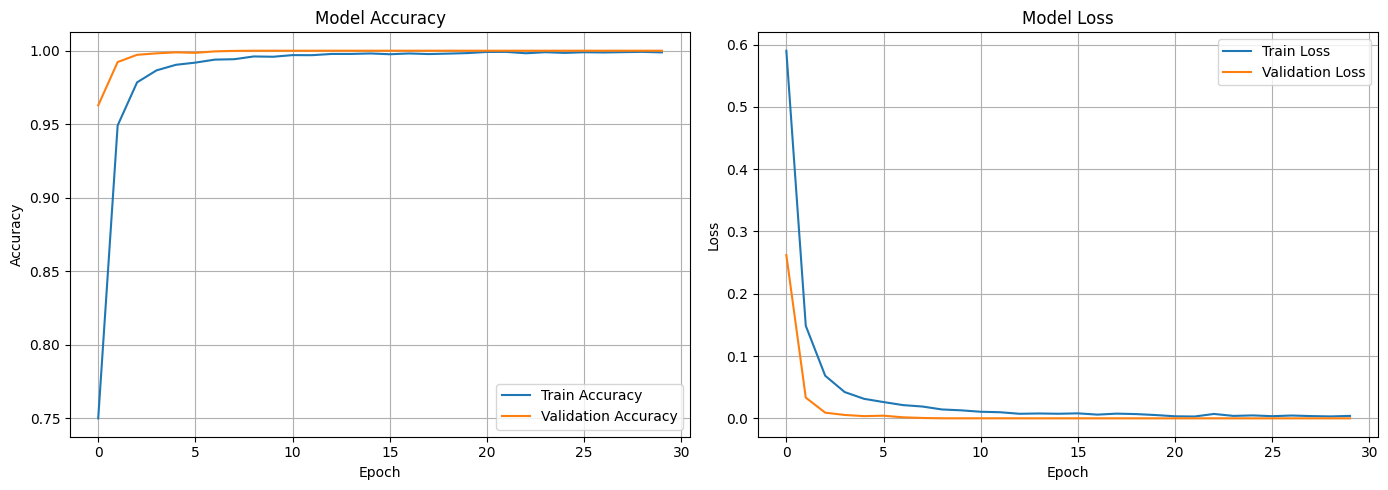

In [31]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Model Evaluation

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions
y_pred_nn_proba = model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_proba, axis=1)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Test Accuracy: 1.0000
Test Loss: 0.0000


## Confusion Matrix

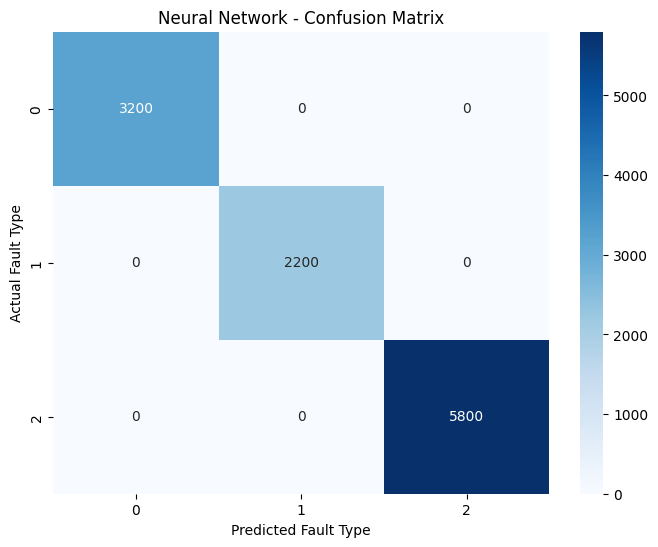

In [33]:
# Compute confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title('Neural Network - Confusion Matrix')
plt.xlabel('Predicted Fault Type')
plt.ylabel('Actual Fault Type')
plt.show()

### Confusion Analysis: Mechanical Interpretation

The confusion matrix reveals which fault types are mechanically similar and thus prone to misclassification. Off-diagonal elements indicate fault pairs with overlapping sensor signatures.

In [34]:
# Analyze confusion patterns
confusion_df = pd.DataFrame(cm_nn, 
                            index=[f'Actual {i}' for i in range(3)],
                            columns=[f'Predicted {i}' for i in range(3)])

print("Confusion Matrix:")
print(confusion_df)

# Identify most confused pairs
cm_normalized = cm_nn.astype('float') / cm_nn.sum(axis=1)[:, np.newaxis]
np.fill_diagonal(cm_normalized, 0)  # Remove diagonal (correct predictions)

max_confusion_idx = np.unravel_index(cm_normalized.argmax(), cm_normalized.shape)
print(f"\nMost confused pair: Fault {max_confusion_idx[0]} misclassified as Fault {max_confusion_idx[1]}")
print(f"Confusion rate: {cm_normalized[max_confusion_idx]:.2%}")

Confusion Matrix:
          Predicted 0  Predicted 1  Predicted 2
Actual 0         3200            0            0
Actual 1            0         2200            0
Actual 2            0            0         5800

Most confused pair: Fault 0 misclassified as Fault 0
Confusion rate: 0.00%


## Classification Report

In [35]:
print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn, target_names=[f'Fault {i}' for i in range(3)]))

Neural Network Classification Report:
              precision    recall  f1-score   support

     Fault 0       1.00      1.00      1.00      3200
     Fault 1       1.00      1.00      1.00      2200
     Fault 2       1.00      1.00      1.00      5800

    accuracy                           1.00     11200
   macro avg       1.00      1.00      1.00     11200
weighted avg       1.00      1.00      1.00     11200



# **Step 6: Neural Network Performance Summary**

## 3-Class Model Performance

Following the consolidation of mechanically similar fault types (Fault 2 + Fault 3 → Fault 2), the neural network now classifies three distinct engine conditions:
- **Fault 0**: Normal/Baseline operation
- **Fault 1**: Rich mixture problems  
- **Fault 2**: Combustion efficiency problems (combined misfire/lean mixture)

In [36]:
from sklearn.metrics import f1_score, accuracy_score

# Neural Network performance summary
nn_results = {
    'Metric': ['Test Accuracy', 'Macro F1', 'Weighted F1'],
    'Score': [
        accuracy_score(y_test, y_pred_nn),
        f1_score(y_test, y_pred_nn, average='macro', zero_division=0),
        f1_score(y_test, y_pred_nn, average='weighted', zero_division=0)
    ]
}

results_df = pd.DataFrame(nn_results)
results_df['Score'] = results_df['Score'].round(4)

print("Neural Network Performance Summary:")
print(results_df.to_string(index=False))

Neural Network Performance Summary:
       Metric  Score
Test Accuracy    1.0
     Macro F1    1.0
  Weighted F1    1.0


# **Step 7: Model Persistence**

Save the trained Neural Network model and preprocessing components for future use:

- **TensorFlow Model**: Saved in Keras format (.keras)
- **Feature Scaler**: StandardScaler for neural network preprocessing


In [38]:
import joblib

# Save Neural Network
model.save('engine_fault_nn_model.keras')

# Save scaler (needed for NN inference)
joblib.dump(scaler, 'feature_scaler.pkl')

print("Neural Network model and scaler saved successfully.")

Neural Network model and scaler saved successfully.
